# Visualize Sam's data

# Importations

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy.optimize import curve_fit
from scipy import signal
import glob

In [2]:
%matplotlib inline

import matplotlib.pyplot as plt

from matplotlib import rc
import matplotlib.colors as mplcolors
from mpltools import annotation

rc('lines', linewidth=1.5, markeredgecolor='k', markeredgewidth=0.5)
rc('xtick', direction='in', labelsize=9)
rc('ytick', direction='in', labelsize=9)

rc('font', family='serif', size=9)
rc('text', usetex=True)

rc('figure', dpi=200)
rc('savefig', dpi=600)

# Auxiliary functions

In [3]:
# Cheat codes

In [4]:
def str2var(string):
    return globals()[string]

In [5]:
# I/O tasks

In [6]:
def sort_B_power(name: str, string: str ='rotation_data_1Hz_'):
    res = name[name.find(string)+len(string):]
    res = res[:res.find('_')]
    res = float(res)
    return res

def folderpath2filepaths(folderpath: str, string: str ='*.csv', sorting_key: None|function=None):
    filepaths = glob.glob(folderpath + string)
    if sorting_key is not None:
        filepaths.sort(key=sorting_key)
    return filepaths

def assemble_filepaths(folderpaths: list, string: str ='*.csv', sorting_key: None|function=None):
    res = []
    for folderpath in folderpaths:
        res = res + folderpath2filepaths(folderpath, string=string, sorting_key=None)
    res.sort(key=sorting_key)
    return res

def choose_condition(folderpaths, string):
    return [folderpath + string for folderpath in folderpaths]

In [7]:
# Data processing

In [155]:
def dedrift(x, method='detrend'):
    if method == 'detrend':
        res = signal.detrend(x, type='linear')
    else: 
        res = x
    return res

In [126]:
# Compute observables

In [127]:
def moment(x: np.ndarray, delta: np.ndarray=np.arange(1,10,1), n: int|float=2, retrieve_mean: bool=False):
    '''
    Moment (order n) of the variable x, for the time steps delta (differences of indexes).
    '''
    res = np.zeros_like(delta) * np.nan
    for i, d in enumerate(delta):
        dx = x[d:] - x[:-d]
        if retrieve_mean:
            res[i] = np.nanmean((dx - np.nanmean(dx)) ** n)
        else:
            res[i] = np.nanmean((dx) ** n)
    return res



In [128]:
def pdf(data, bins=10, density=True, range=None):
    pdf, bins_edge = np.histogram(
        data, 
        bins=bins, 
        density=density, 
        range=range, 
    )
    bins_center = (bins_edge[0:-1] + bins_edge[1:]) / 2
    return pdf, bins_center

In [129]:
# Theoretical functions

In [785]:
def gaussian(x, a, b):
    return b * np.exp(- x ** 2 / (2 * a ** 2))

def gaussian_brownian(x, D, t):
    return gaussian(x, np.sqrt(2*D*t), 1/np.sqrt(4*np.pi*D*t))

# Info on files

In [131]:
glob.glob('../sam/shell_stuck_on_surface/TriAmineChip2/*')

['../sam/shell_stuck_on_surface/TriAmineChip2/position1_neutral_pH_start',
 '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-3',
 '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_10-5_NaCl_10-4',
 '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-5',
 '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_10-5_NaCl_10-3']

In [132]:
glob.glob('../sam/shell_stuck_on_surface/TriAmineChip3/*')

['../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_2_going_back_from_salt',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_10-5_NaCl_10-3',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_10-5_NaCl_10-3',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_1e-5',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_2_going_back_from_salt',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3']

# Load data

In [133]:
# One experimental condition

folderpaths_0 = [
    '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_10-5_NaCl_10-3/', 
    '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/', 
    '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_10-5_NaCl_10-3/', 
    '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_10-5_NaCl_10-3/', 
]

# DO NOT FORGET THE LAST / IN THE FILE PATHS ABOVE

folderpaths_0_1 = choose_condition(folderpaths_0, string='1.0Hz/')
filepaths_0_1 = assemble_filepaths(folderpaths_0_1, string='*.csv', sorting_key=sort_B_power)

folderpaths_0_0 = choose_condition(folderpaths_0, string='0.0Hz/')
filepaths_0_0 = assemble_filepaths(folderpaths_0_0, string='*.csv', sorting_key=None)[:]

filepaths_0_0

['../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_2_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_2_particle_2.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surf

In [134]:
# Another experimental condition

folderpaths_1 = [
    '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-5/',
    '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_1e-5/',
]

folderpaths_1_1 = choose_condition(folderpaths_1, string='1.0Hz/')
filepaths_1_1 = assemble_filepaths(folderpaths_1_1, string='*.csv', sorting_key=sort_B_power)

folderpaths_1_0 = choose_condition(folderpaths_1, string='0.0Hz/')
filepaths_1_0 = assemble_filepaths(folderpaths_1_0, string='*.csv', sorting_key=None)

filepaths_1_0

['../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-5/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_1e-5/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_1e-5/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv']

In [135]:
folderpaths_2 = [
    '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_2_going_back_from_salt/', 
    '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/', 
    '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_2_going_back_from_salt/', 
]

folderpaths_2_1 = choose_condition(folderpaths_2, string='1.0Hz/')
filepaths_2_1 = assemble_filepaths(folderpaths_2_1, string='*.csv', sorting_key=sort_B_power)

folderpaths_2_0 = choose_condition(folderpaths_2, string='0.0Hz/')
filepaths_2_0 = assemble_filepaths(folderpaths_2_0, string='*.csv', sorting_key=None)

filepaths_2_0 = filepaths_2_0[:-2]

filepaths_2_0

['../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_2_going_back_from_salt/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_2_going_back_from_salt/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv']

In [136]:
# Calib 

calib = 130e-9

# Calib to be checked ! 

In [695]:
filepaths = filepaths_2_0

filepaths

['../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_2_going_back_from_salt/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_2_going_back_from_salt/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv']

In [696]:
Ns = np.zeros(len(filepaths), dtype=int)
dts = np.zeros(len(filepaths), dtype=float)

for i, path in enumerate(filepaths):
    df = pd.read_csv(path)
    # Number of frames
    Ns[i] = int(len(df['frame']))
    # Frame rate / time step
    time = df['time_sec'].to_numpy()
    dt = np.nanmean(time[1:] - time[:-1])
    dt = np.round(dt, 4)
    dts[i] = dt

# fps = 1000

# Ns = np.zeros(len(filepaths), dtype=int)
# dts = np.zeros(len(filepaths), dtype=float)

# for i, path in enumerate(filepaths):
#     df = pd.read_pickle(path)
#     # Number of frames
#     Ns[i] = int(len(df['frame']))
#     # Frame rate / time step
#     time = np.arange(len(df)) / fps #df['time_sec'].to_numpy()
#     dt = np.nanmean(time[1:] - time[:-1])
#     dt = np.round(dt, 4)
#     dts[i] = dt

# print(Ns)
print('Length of the shortest trajectory:')
print(min(Ns))

print()
print('Time step (in s) of all the trajectories:')
print(dts)


Length of the shortest trajectory:
34951

Time step (in s) of all the trajectories:
[0.001 0.001 0.001 0.001]


In [697]:
dt = dts[0]

In [698]:
df.head()

,frame,time_sec,principal_angle_deg,principal_angle_180_deg,principal_angle_360_deg,delta_angle_deg,cumulative_rotation_deg,delta_angle_deg_180,cumulative_rotation_deg_180,com_x_px,com_y_px
0,0,0.000,40.001717,40.001717,310.001717,0.000000,0.000000,0.000000,0.000000,227.767663,115.725312
1,1,0.001,39.390930,39.390930,309.390930,-0.610786,-0.610786,-0.610786,-0.610786,227.770736,115.725764
2,2,0.002,39.390930,39.390930,309.390930,0.000000,-0.610786,0.000000,-0.610786,227.770736,115.725764
3,3,0.003,39.501038,39.501038,309.501038,0.110107,-0.500679,0.110107,-0.500679,227.771693,115.724712
4,4,0.004,39.501038,39.501038,309.501038,0.000000,-0.500679,0.000000,-0.500679,227.771693,115.724712


In [911]:
Ntime = min(Ns)
Ntraj = len(filepaths)
datas = np.zeros((Ntime, 4, Ntraj))

for i, path in enumerate(filepaths):
    df = pd.read_csv(path)
    df = df[:Ntime]
    time = df['time_sec'].to_numpy()
    # theta1 = df['principal_angle_deg'].to_numpy()
    # theta2 = df['principal_angle_180_deg'].to_numpy()
    xpx = df['com_x_px'].to_numpy()
    ypx = df['com_y_px'].to_numpy()
    x = xpx * calib
    y = ypx * calib
    theta3 = df['principal_angle_360_deg'].to_numpy()
    datas[:,0,i] = np.copy(time)
    # datas[:,1,i] = np.copy(theta1)
    # datas[:,2,i] = np.copy(theta2)
    datas[:,1,i] = np.copy(x)
    datas[:,2,i] = np.copy(y)
    datas[:,3,i] = np.copy(theta3)

del df, time, xpx, ypx, theta3

In [912]:
datas = datas[:,:,:]

In [913]:
np.shape(datas)[-1]

4

In [914]:
indexes = np.arange(np.shape(datas)[-1]) 
# indexes = np.arange(10)

In [915]:
# for i in indexes:
#     print(sort_B_power(filepaths[i]))

In [916]:
colors = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=False, n=len(filepaths))

In [917]:
indexes

array([0, 1, 2, 3])

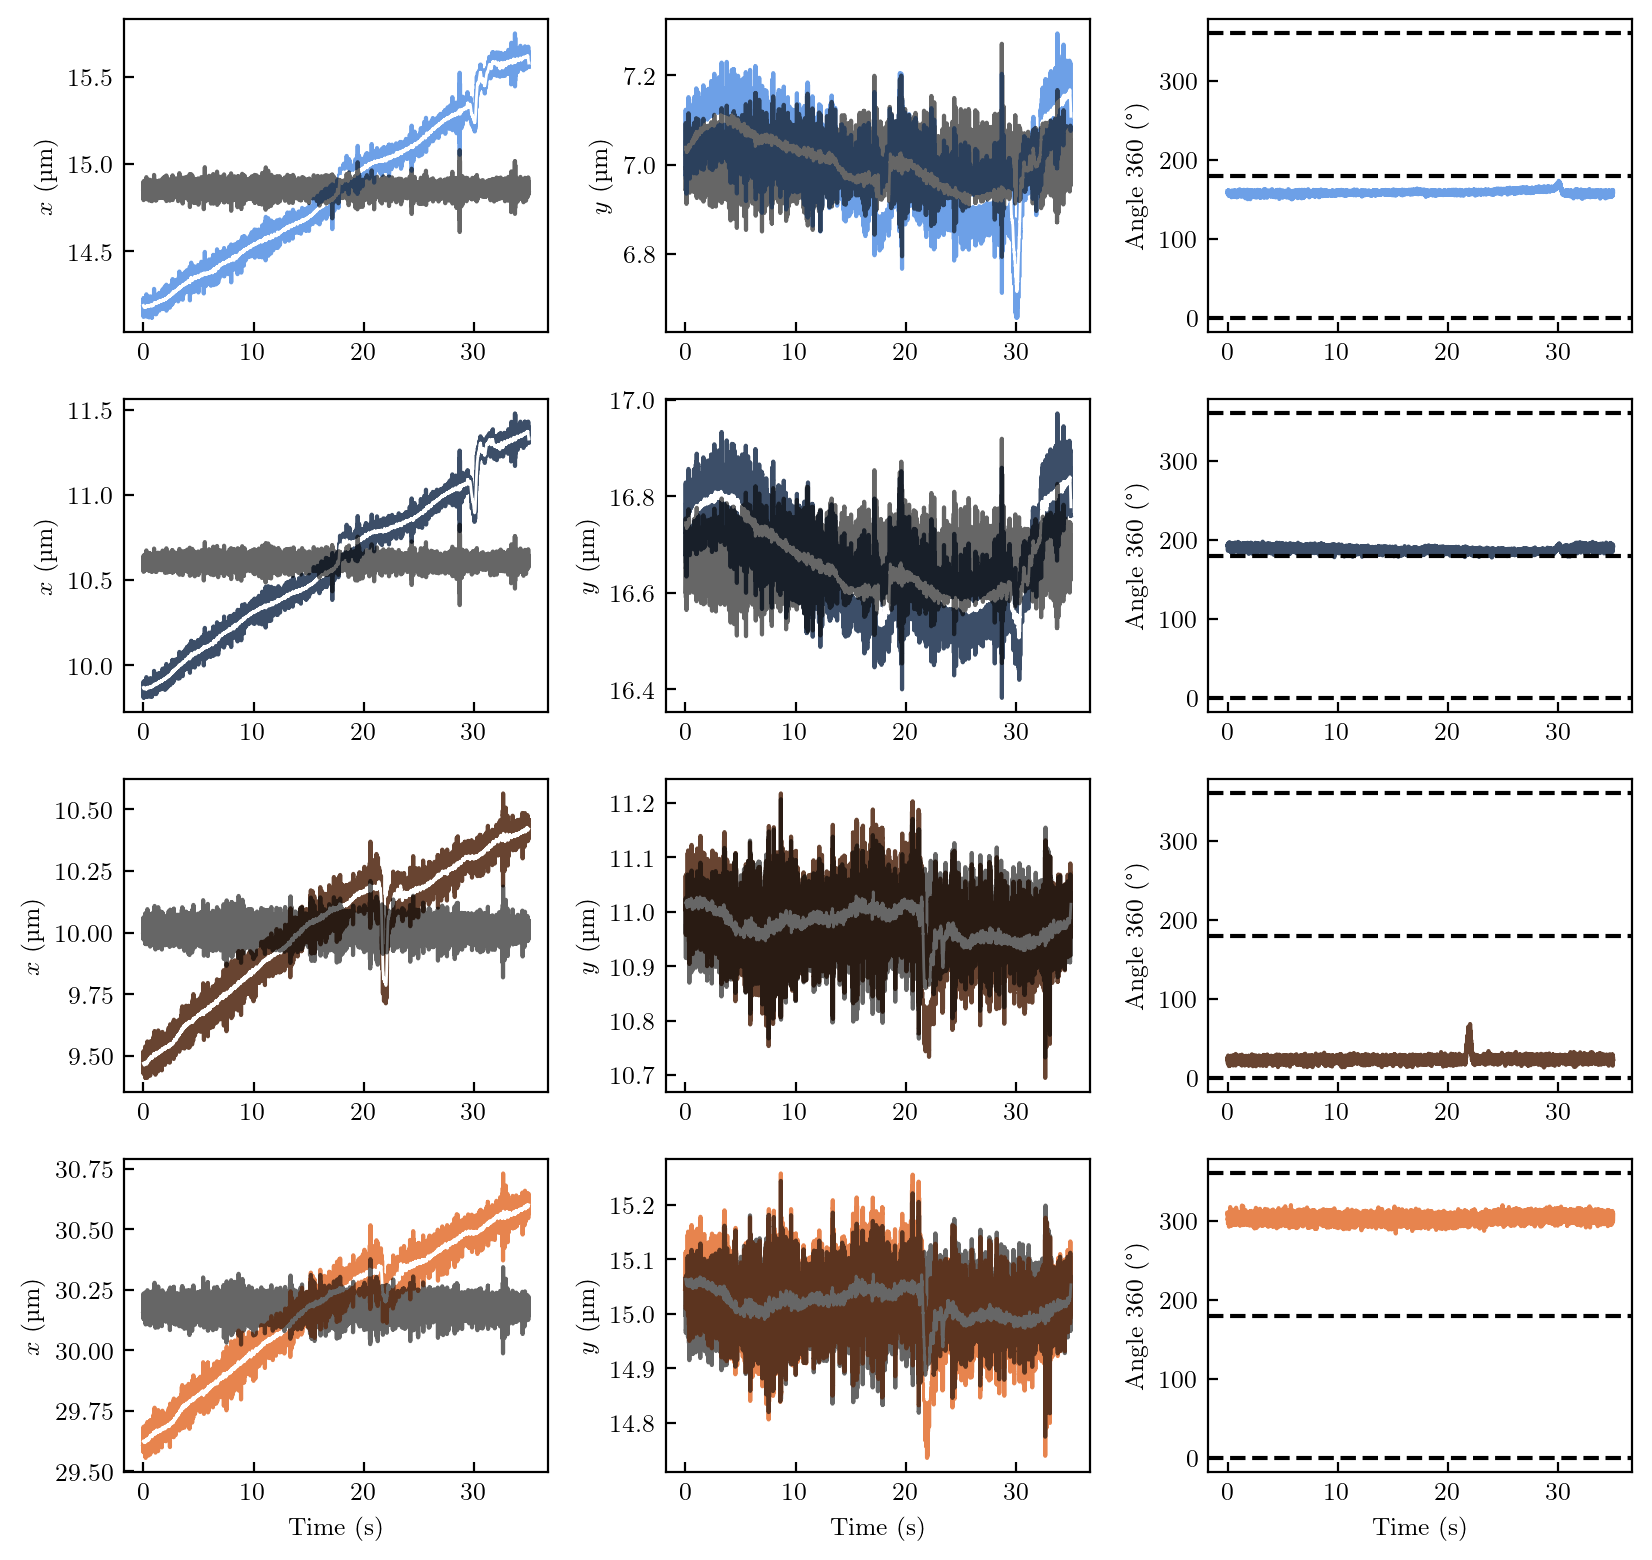

In [918]:
fig, axes = plt.subplots(len(indexes), 3, figsize=(21/2.54, int(len(indexes)*5)/2.54))

for i, ind in enumerate(indexes[::]):

    time = datas[:,0,ind]
    x = datas[:,1,ind]
    y = datas[:,2,ind]
    theta = datas[:,3,ind]

    # xd = signal.detrend(x, type='linear')
    # yd = signal.detrend(y, type='linear')

    window = 101
    polyorder = 1

    xsmooth = signal.savgol_filter(x, window, polyorder)
    ysmooth = signal.savgol_filter(y, window, polyorder)

    xd = x - xsmooth
    yd = y - ysmooth

    start = 0
    stop = len(time) #// 10

    axes[i, 0].plot(time[start:stop], x[start:stop] * 1e6, ls='-', color=colors[ind])
    axes[i, 0].plot(time[start:stop], xsmooth[start:stop] * 1e6, ls='-', lw=1, color='white')
    axes[i, 0].plot(time[start:stop], xd[start:stop] * 1e6 + np.nanmean(x) * 1e6, ls='-', color='k', alpha=0.6)
    axes[i, 1].plot(time[start:stop], y[start:stop] * 1e6, ls='-', color=colors[ind])
    axes[i, 1].plot(time[start:stop], ysmooth[start:stop] * 1e6, ls='-', lw=1, color='white')
    axes[i, 1].plot(time[start:stop], yd[start:stop] * 1e6 + np.nanmean(y) * 1e6, ls='-', color='k', alpha=0.6)
    axes[i, 2].plot(time[start:stop], theta[start:stop], ls='-', color=colors[ind])

    # axes[i,2].plot(datas[start:stop,0,0], datas[start:stop,3,0], ls='-')1e-5/1.0Hz/

    axes[i,2].axhline(y=180, ls='--', c='k')
    axes[i,2].axhline(y=0, ls='--', c='k')
    axes[i,2].axhline(y=360, ls='--', c='k')

    datas[:,1,ind] = np.copy(xd)
    datas[:,2,ind] = np.copy(yd)

for j in range(3):
    axes[-1, j].set_xlabel('Time (s)')

for i in range(len(indexes)):
    axes[i, 0].set_ylabel(r'$x$ (\textmu m)')
    axes[i, 1].set_ylabel(r'$y$ (\textmu m)')
    axes[i, 2].set_ylabel('Angle 360 (°)')

del time, x, y, theta, start, stop, xd, yd

plt.tight_layout()
plt.show()

In [919]:
# tokeep = [0, 1, 2, 4, 6]

# datas = datas[:,:,tokeep]

# filepaths = [filepaths[i] for i in tokeep]
# colors = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=False, n=len(filepaths))
# indexes = np.arange(len(filepaths))

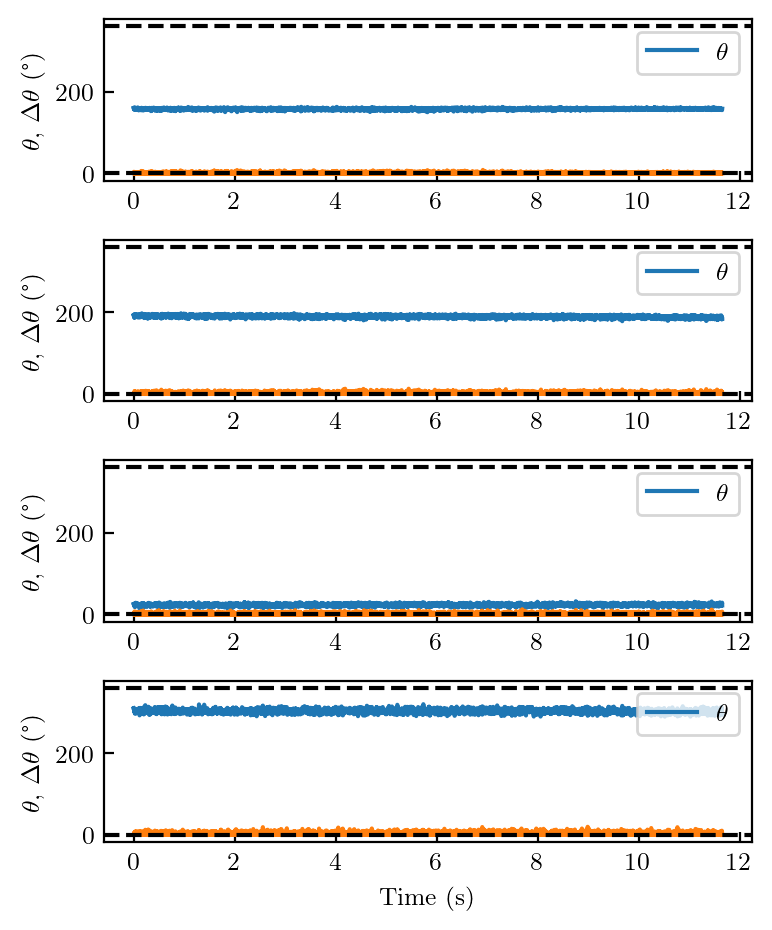

In [920]:
fig, axes = plt.subplots(len(indexes), 1, figsize=(10/2.54, 3*len(indexes)/2.54))

for i, k in enumerate(indexes):
    
    time = datas[:, 0, k]
    theta = datas[:, 3, k]

    dtheta = np.abs(theta[1:]  - theta[:-1])

    start = 0
    stop = len(theta) // 3

    axes[i].plot(time[start:stop], theta[start:stop], ls='-', label=r'$\theta$')
    axes[i].plot(time[start:stop], dtheta[start:stop], ls='-')

for i in range(len(axes)): 
    # axes[i].axhline(y=180, ls='--', c='k')
    axes[i].axhline(y=0, ls='--', c='k')
    axes[i].axhline(y=360, ls='--', c='k')
    # axes[i].axhline(y=-360, ls='--', c='k')
    # axes[i].axhline(y=-180, ls='--', c='k')
    axes[i].set_ylabel(r'$\theta, \, \Delta \theta$ (°)')
    axes[i].legend(loc='upper right')
axes[-1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

In [921]:
dframes = np.concatenate((np.arange(1, 100, 1), np.arange(100, 10000, 100)))
# dtimes = dframes * dt

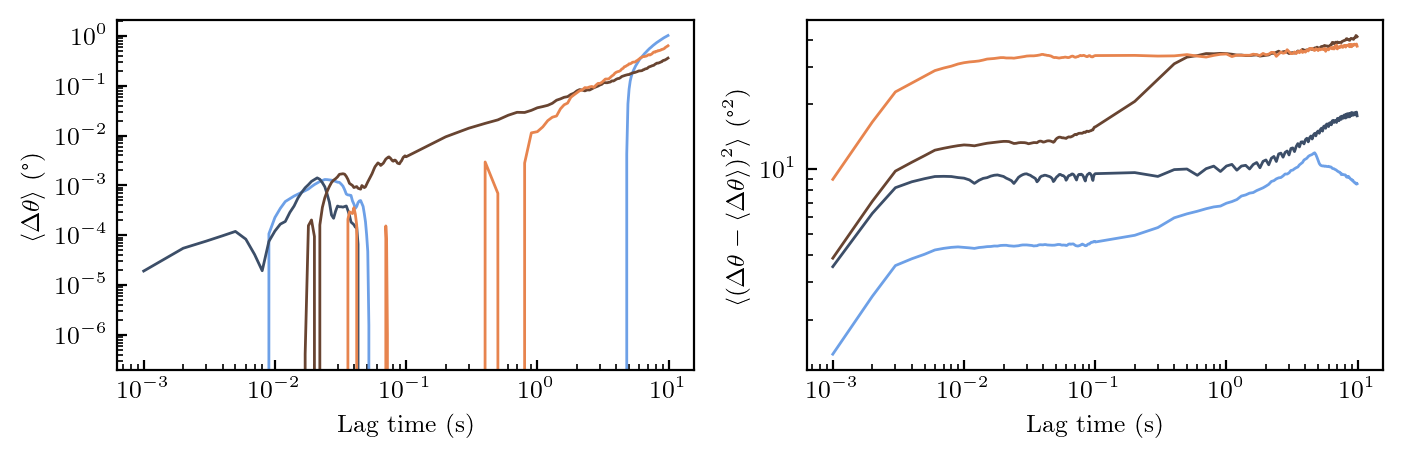

In [922]:
fig, axes = plt.subplots(1, 2, figsize=(18/2.54, 6/2.54))

for i, k in enumerate(indexes):

    dtimes = dframes * dts[k]
    
    theta = datas[:, 3, k]

    m1 = moment(theta, dframes, n=1, retrieve_mean=False)
    msd = moment(theta, dframes, n=2, retrieve_mean=True)

    axes[0].plot(dtimes, m1, ls='-', color=colors[k], lw=1)
    axes[1].plot(dtimes, msd, ls='-', color=colors[k], lw=1) # marker='o', ms=2, mew=0.2, mec='k', mfc=colors[k])

axes[0].set_ylabel(r'$\langle \Delta \theta \rangle$ (°)')
axes[0].set_xlabel('Lag time (s)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[1].set_ylabel(r'$\langle \left( \Delta \theta -  \langle \Delta \theta \rangle \right) ^2 \rangle$ (°$^2$)')
axes[1].set_xlabel('Lag time (s)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

[1.64070819e-13 9.49707603e-09]
[1.63205984e-13 8.94338107e-09]
[ 1.95386651e-13 -3.32585846e-13]
[1.93539740e-13 2.99368964e-13]


/tmp/ipykernel_28934/1098615723.py:24: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(linear, dtimes[0:10], msdr[0:10], p0=[1e-14, 0])


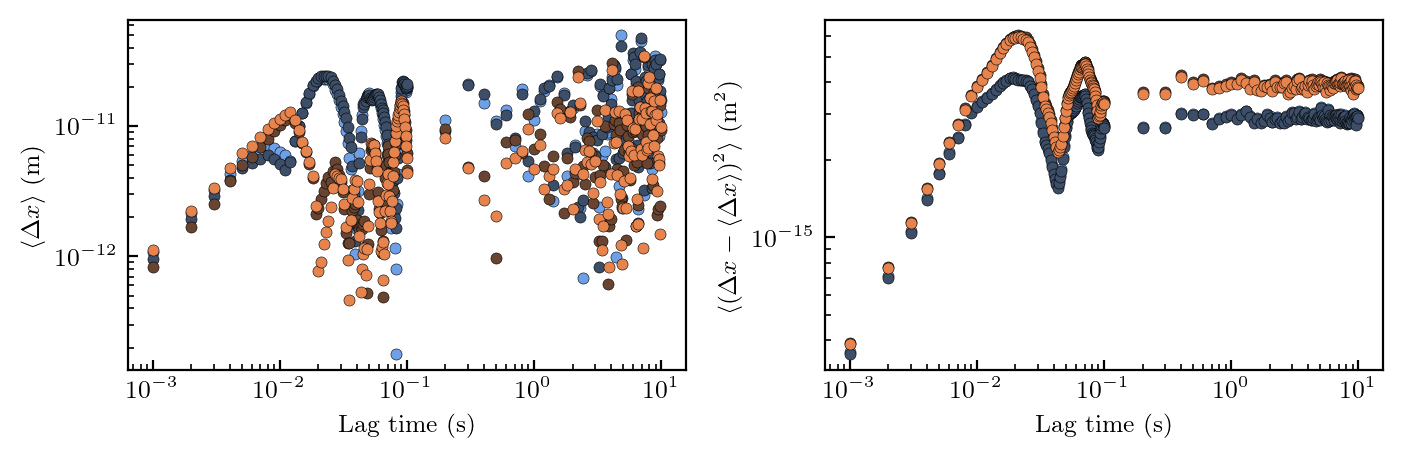

In [923]:
fig, axes = plt.subplots(1, 2, figsize=(18/2.54, 6/2.54))

for i, k in enumerate(indexes):
    
    x = datas[:, 1, k]
    y = datas[:, 2, k]

    m1x = moment(x, dframes, n=1, retrieve_mean=False)
    msdx = moment(x, dframes, n=2, retrieve_mean=True)
    m1y = moment(y, dframes, n=1, retrieve_mean=False)
    msdy = moment(y, dframes, n=2, retrieve_mean=True)

    m1r = (np.abs(m1x) + np.abs(m1y)) / 2
    msdr = (msdx + msdy) / 2

    start = 0
    stop = 10000

    axes[0].plot(dtimes[start:stop], m1r[start:stop], ls='', marker='o', color=colors[k], ms=4, mew=0.2)
    axes[1].plot(dtimes[start:stop], msdr[start:stop], ls='', marker='o', color=colors[k], ms=4, mew=0.2) # marker='o', ms=2, mew=0.2, mec='k', mfc=colors[k])

    linear = lambda x, a, b: 2*a*x + b**2

    popt, _ = curve_fit(linear, dtimes[0:10], msdr[0:10], p0=[1e-14, 0])

    # axes[1].plot(dtimes[start:stop], linear(dtimes, *popt)[start:stop], ls='-', marker='', color=colors[k])

    print(popt)


axes[0].set_ylabel(r'$\langle \Delta x \rangle$ (m)')
axes[0].set_xlabel('Lag time (s)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[1].set_ylabel(r'$\langle \left( \Delta x -  \langle \Delta x \rangle \right) ^2 \rangle$ (m$^2$)')
axes[1].set_xlabel('Lag time (s)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

[2.02048757 0.18992379]
1.979720171877128e-21

[3.37306516 0.121526  ]
1.1858650232050324e-21

[2.63173672 0.14934943]
1.519908877785891e-21

[4.34822144 0.09191556]
9.199163501501426e-22



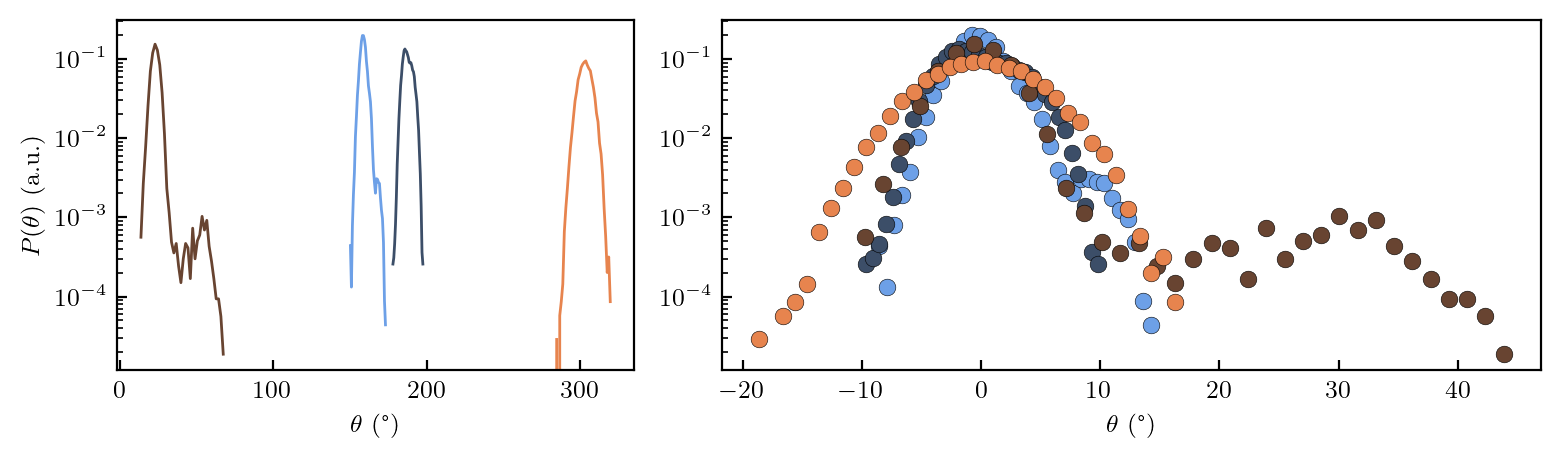

In [924]:
fig = plt.figure(figsize=(20/2.54, 6/2.54))

ax1 = fig.add_subplot(1, 5, (1,2))
ax2 = fig.add_subplot(1, 5, (3,5))

for i, k in enumerate(indexes):
    
    theta = datas[:, 3, k]

    prob, bins = pdf(theta, bins=36)
    prob = prob / np.trapezoid(prob, bins)

    ax1.plot(bins, prob, ls='-', color=colors[k], lw=1)

    # Recentering theta
    thetab = theta - np.nanmean(theta)
    prob, bins = pdf(thetab[thetab < 50], bins=36)
    prob = prob / np.trapezoid(prob, bins)

    ax2.plot(bins, prob, ls='', marker='o', color=colors[k], mew=0.2)

    popt, _ = curve_fit(gaussian, bins, prob, p0=[1,1])
    # ax2.plot(bins, gaussian(bins, *popt), ls='-', color=colors[k])
    
    print(popt)
    print(4e-21 / popt[0])
    print()

ax1.set_ylabel(r'$P(\theta)$ (a.u.)')
for ax in [ax1, ax2]:
    ax.set_xlabel(r'$\theta$ (°)')
    # ax.set_xscale('log')
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [925]:
dframes_bis = np.array([3, 5, 10, 15])

In [926]:
def compute_pdf(dx : np.ndarray, cutoff : float = 10, bins : int|np.ndarray = 30, normalize: bool = True):
    sample = dx[np.abs(dx) < cutoff]
    prob, bins = pdf(sample[~np.isnan(sample)], bins=bins)
    if normalize:
        prob = prob / np.trapezoid(prob, bins)
    return prob, bins

In [927]:
def plotfit_pdf(datas, indexes, dframes):
    fig, axes = plt.subplots(2, len(dframes), figsize=(7*len(dframes)/2.54, 12/2.54))

    for i, k in enumerate(indexes):
        x = datas[:, 1, k]
        y = datas[:, 2, k]
        theta = datas[:, 3, k]
        times = datas[:, 0, k]

        for j, d in enumerate(dframes):

            dtheta = theta[d:] - theta[:-d]
            dx = x[d:] - x[:-d]
            dy = y[d:] - y[:-d]
            # dr = np.sqrt(dx ** 2 + dy ** 2)
            dxy = np.concatenate([dx, dy])

            prob, bins = compute_pdf(dtheta, cutoff=3*np.nanstd(dtheta), bins=30)

            axes[0,j].plot(bins, prob, ls='', marker='o', color=colors[k], mew=0.2, ms=4)

            if j != 0:
            # popt, _ = curve_fit(gaussian, bins, prob, p0=[1, 1])
            # axes[0,j].plot(bins, gaussian(bins, *popt), ls='-', color=colors[k], lw=1.5)
                pass
            
            if j == 0:
                threshold = 2   # threshold to be investigated
                # popt, _ = curve_fit(gaussian, bins[bins > threshold], prob[bins > threshold], p0=[1, 1])
                # axes[0,j].plot(bins, gaussian(bins, *popt), ls='-', color=colors[k], lw=1.5)
                # Artificially correct the distributions
                index = np.abs(bins) < threshold
                # prob[index] = gaussian(bins[index], *popt)
                # axes[0,j].plot(bins, prob, ls='', marker='d', color=colors[k], mew=0.2, ms=4)

            prob, bins = compute_pdf(dxy, cutoff=3*np.nanstd(dxy), bins=30)

            axes[1,j].plot(bins*1e6, prob*1e-6, ls='', marker='o', color=colors[k], mew=0.2, ms=4)

            if j >= 2:
                popt, _ = curve_fit(gaussian, bins, prob, p0=[1e-6, 1e6])
                # popt, _ = curve_fit(lambda x, a, b: np.log10(gaussian(x, a, b)), bins, np.log10(prob), p0=[1e-6, 1e6])
                axes[1,j].plot(bins*1e6, gaussian(bins, *popt)*1e-6, ls='-', color=colors[k], lw=1.5)
                # print(np.nanstd(prob))
                # print(np.nanstd(gaussian(bins, *popt)))
                # print()
            
            # if j == 0:
            #     threshold = 50e-9   # threshold to be investigated
            #     popt, _ = curve_fit(gaussian, bins[bins > threshold], prob[bins > threshold], p0=[1e-6, 1e6])
            #     axes[1,j].plot(bins*1e6, gaussian(bins, *popt)*1e-6, ls='-', color=colors[k], lw=1.5)
            #     # Artificially correct the distributions
            #     index = np.abs(bins) < threshold
            #     prob[index] = gaussian(bins[index], *popt)
            #     axes[1,j].plot(bins*1e6, prob*1e-6, ls='', marker='d', color=colors[k], mew=0.2, ms=4)

            # axes[1,j].plot(bins*1e6, gaussian_brownian(bins, 1.63e-13, times[d]-times[0])*1e-6, ls='-.', c='k')
            # axes[1,j].plot(bins*1e6, gaussian_brownian(bins, 1.94e-13, times[d]-times[0])*1e-6, ls='--', c='tab:red')

    for j, ax in enumerate(axes[0,:]):
        ax.set_xlabel(r'$\Delta\theta$ (°)')
        ax.set_yscale('log')
    axes[0,0].set_ylabel(r'$P(\Delta\theta)$ (a.u.)')
    for j, ax in enumerate(axes[1,:]):
        ax.set_xlabel(r'$\Delta r$ (\textmu m)')
        ax.set_yscale('log')
    axes[1,0].set_ylabel(r'$P(\Delta r)$ (a.u.)')
    plt.tight_layout()
    plt.show()

    print(dframes * dt)

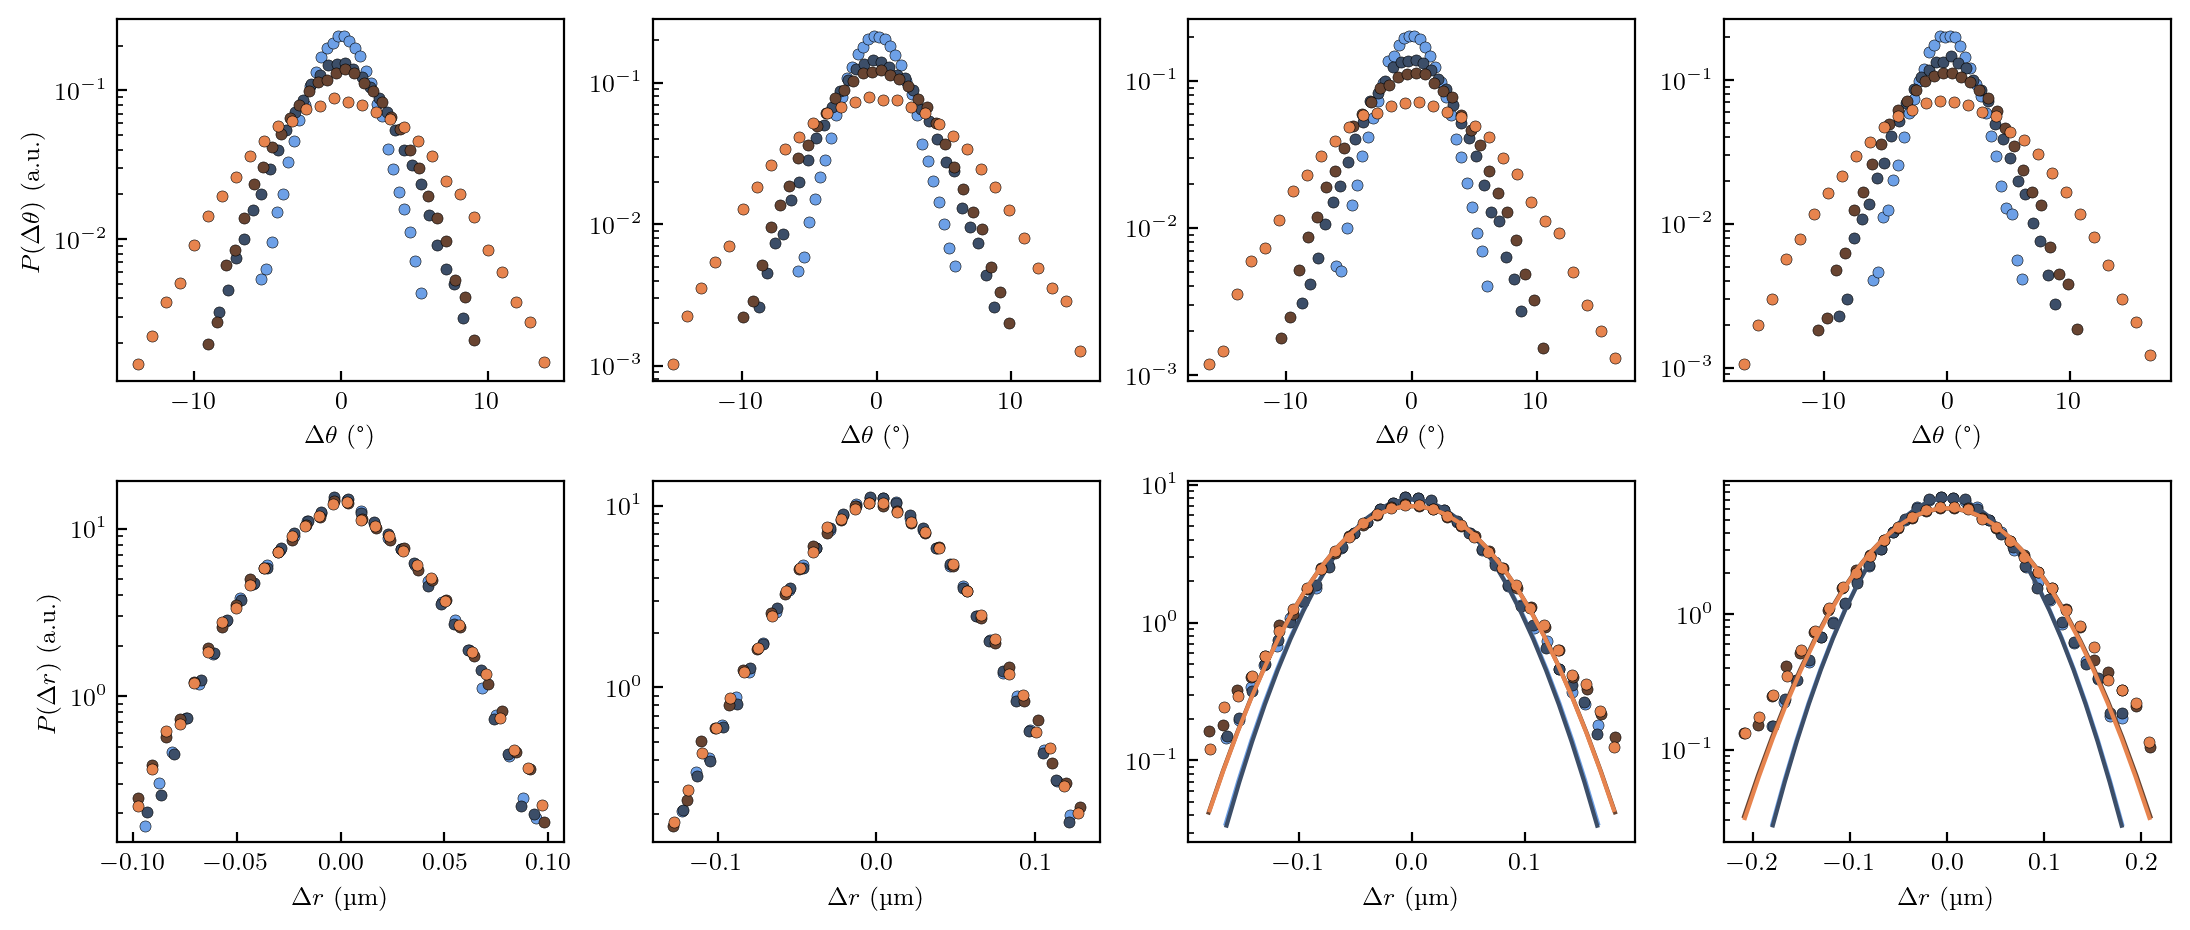

[0.003 0.005 0.01  0.015]


In [928]:
plotfit_pdf(datas, indexes, dframes_bis)

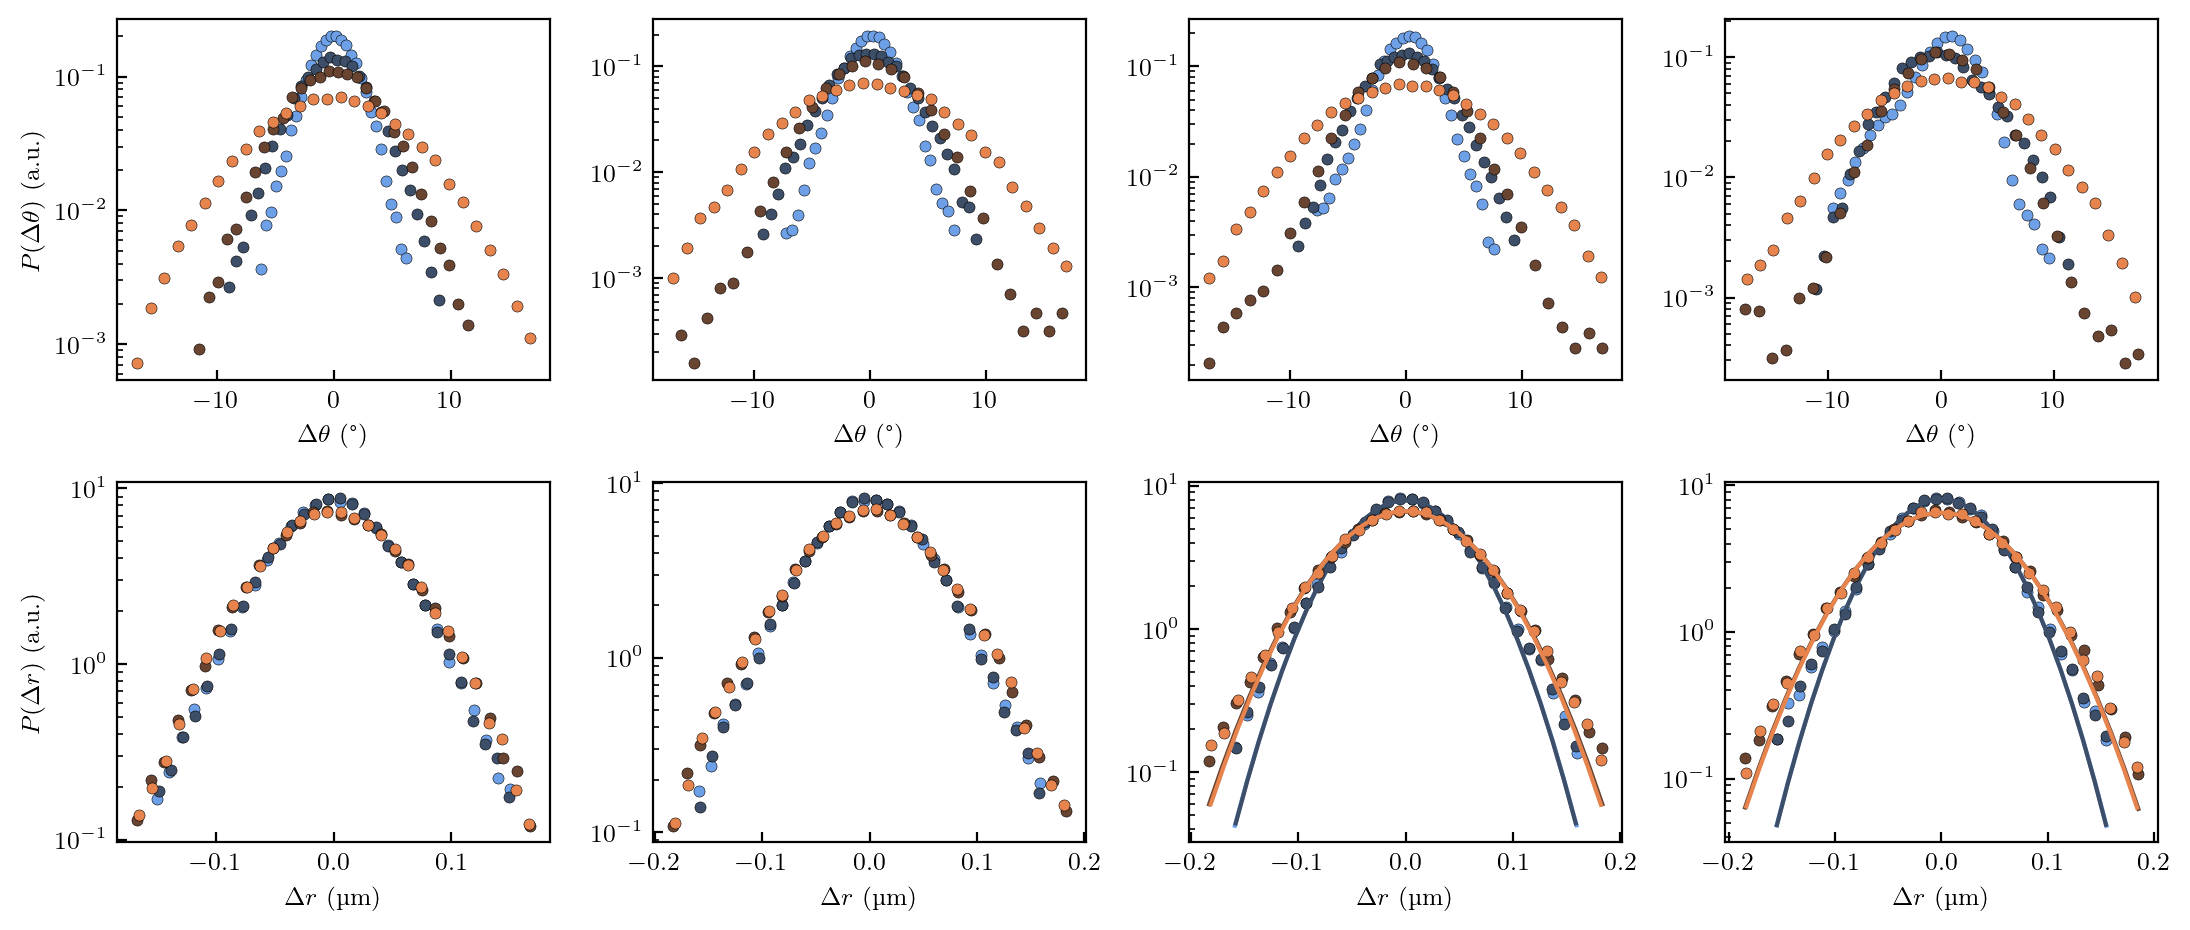

[0.1 0.5 1.  5. ]


In [929]:
dframes_ter = np.array([100, 500, 1000, 5000])

plotfit_pdf(datas, indexes, dframes_ter)

In [730]:
def Cxy(x: np.ndarray, y:np.ndarray, lags: np.ndarray=np.arange(1,10,1), retrieve_mean: bool=False):
    if retrieve_mean:
        x = x - np.nanmean(x)
        y = y - np.nanmean(y)
    res = np.zeros_like(lags) * np.nan
    for i, d in enumerate(lags):
        res[i] = np.nanmean(x[:-d] * y[d:])
    return res

def Cxy_fft(x: np.ndarray, y:np.ndarray, retrieve_mean: bool=False):
    if retrieve_mean:
        x = x - np.mean(x)
        y = y - np.mean(y)
    N = len(x)
    fx = np.fft.rfft(x, n=2*N)
    fy = np.fft.rfft(y, n=2*N)
    res = np.fft.irfft(fx * np.conj(fy))[:N]
    # res /= (N - np.arange(N)) # to unbias, but I don't understand
    return res

# def Cdxdy(x: np.ndarray, y:np.ndarray, lags: np.ndarray=np.arange(1,10,1), retrieve_mean: bool=False):
#     res = np.zeros_like(lags) * np.nan
#     if retrieve_mean:
#         for i, d in enumerate(lags):
#             dx = x[d:-d] - x[:-int(2*d)]
#             dy = y[int(2*d):] - y[d:-d]
#             res[i] = np.nanmean((dx - np.nanmean(dx)) * (dy - np.nanmean(dy)))
#     else:
#         for i, d in enumerate(lags):
#             dx = x[d:-d] - x[:-int(2*d)]
#             dy = y[int(2*d):] - y[d:-d]
#             res[i] = np.nanmean(dx * dy)
#     return res

def Cdxdy(x: np.ndarray, y:np.ndarray, lags: np.ndarray=np.arange(1,10,1), disp: int=1, retrieve_mean: bool=False):
    dx = x[disp:] - x[:-disp]
    dy = y[disp:] - y[:-disp]
    return Cxy(x=dx, y=dy, lags=lags, retrieve_mean=retrieve_mean)

def Cdxdy_fft(x: np.ndarray, y:np.ndarray, disp: int=1, retrieve_mean: bool=False):
    dx = x[disp:] - x[:-disp]
    dy = y[disp:] - y[:-disp]
    return Cxy_fft(x=dx, y=dy, retrieve_mean=retrieve_mean)

In [731]:
dframes = np.concatenate((np.arange(1, 100, 1), np.arange(100, 10000, 1)))
dtimes = dframes * dt

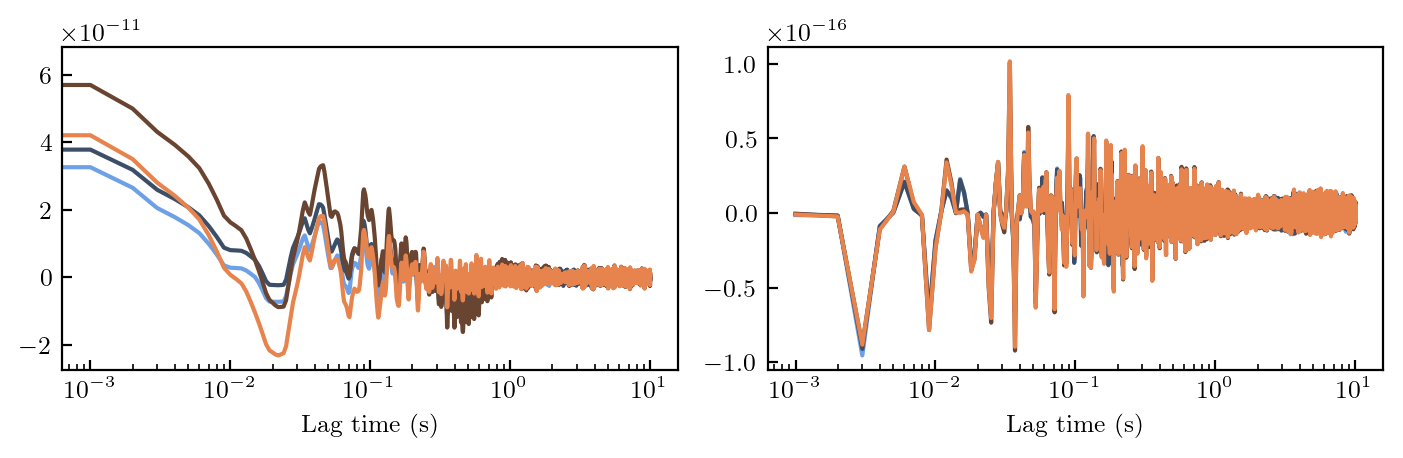

In [732]:
fig, axes = plt.subplots(1, 2, figsize=(18/2.54, 6/2.54))

for i, k in enumerate(indexes):
    
    x = datas[:, 1, k]
    y = datas[:, 2, k]
    theta = datas[:, 3, k]

    xd = x #signal.detrend(x, type='linear')

    # cxx = Cxy(x, y, lags=np.arange(len(x)), retrieve_mean=True)
    cxy = Cxy_fft(xd, xd, retrieve_mean=True)
    # cxy = autocorrelation_biased(x)
    cdxdtheta = Cdxdy(xd, xd, dframes[:], disp=1, retrieve_mean=True)

    axes[0].plot(np.arange(len(x))[:10000] * dt, cxy[:10000], ls='-', marker='', color=colors[k], mew=0.2)
    axes[1].plot(dtimes[:], cdxdtheta, ls='-', marker='', color=colors[k], mew=0.1, ms=3)

# axes[0].set_ylabel(r'$\langle \Delta x \rangle$ (m)')
axes[0].set_xlabel('Lag time (s)')
axes[0].set_xscale('log')
# axes[0].set_yscale('log')
# axes[1].set_ylabel(r'$\langle \left( \Delta x -  \langle \Delta x \rangle \right) ^2 \rangle$ (m$^2$)')
axes[1].set_xlabel('Lag time (s)')
axes[1].set_xscale('log')
# axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

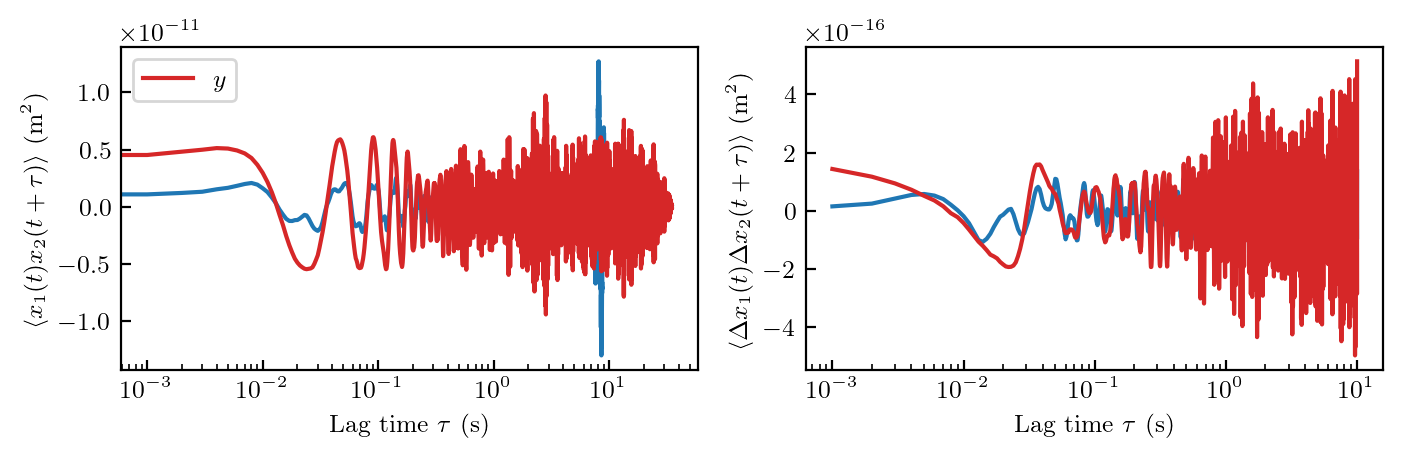

In [733]:
i1 = 1
i2 = 2

x1 = datas[:,1,i1]
y1 = datas[:,2,i1]
x2 = datas[:,1,i2]
y2 = datas[:,2,i2]

cx1x2 = Cxy_fft(x1, x2, retrieve_mean=True)
cy1y2 = Cxy_fft(y1, y2, retrieve_mean=True)

cdx1dx2 = Cdxdy(x1, x2, lags=dframes, disp=10, retrieve_mean=True)
cdy1dy2 = Cdxdy(y1, y2, lags=dframes, disp=10, retrieve_mean=True)
# cdx1dx2 = Cdxdy(x1, x2, lags=dframes, retrieve_mean=True)
# cdy1dy2 = Cdxdy(y1, y2, lags=dframes, retrieve_mean=True)

fig, axes = plt.subplots(1, 2, figsize=(18/2.54, 6/2.54))

axes[0].plot(np.arange(len(x1)) * dt, cx1x2, ls='-', marker='', color='tab:blue', mew=0.2)
axes[0].plot(np.arange(len(y1)) * dt, cy1y2, ls='-', marker='', color='tab:red', mew=0.2, label=r'$y$')

axes[1].plot(dtimes, cdx1dx2, ls='-', marker='', color='tab:blue', mew=0.2)
axes[1].plot(dtimes, cdy1dy2, ls='-', marker='', color='tab:red', mew=0.2)

axes[0].legend()

axes[0].set_ylabel(r'$\langle x_1(t) x_2(t+\tau) \rangle$ (m$^2$)')
axes[0].set_xlabel(r'Lag time $\tau$ (s)')
axes[0].set_xscale('log')
# axes[0].set_yscale('log')
axes[1].set_ylabel(r'$\langle \Delta x_1(t) \Delta x_2(t+\tau) \rangle$ (m$^2$)')
axes[1].set_xlabel(r'Lag time $\tau$ (s)')
axes[1].set_xscale('log')
# axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

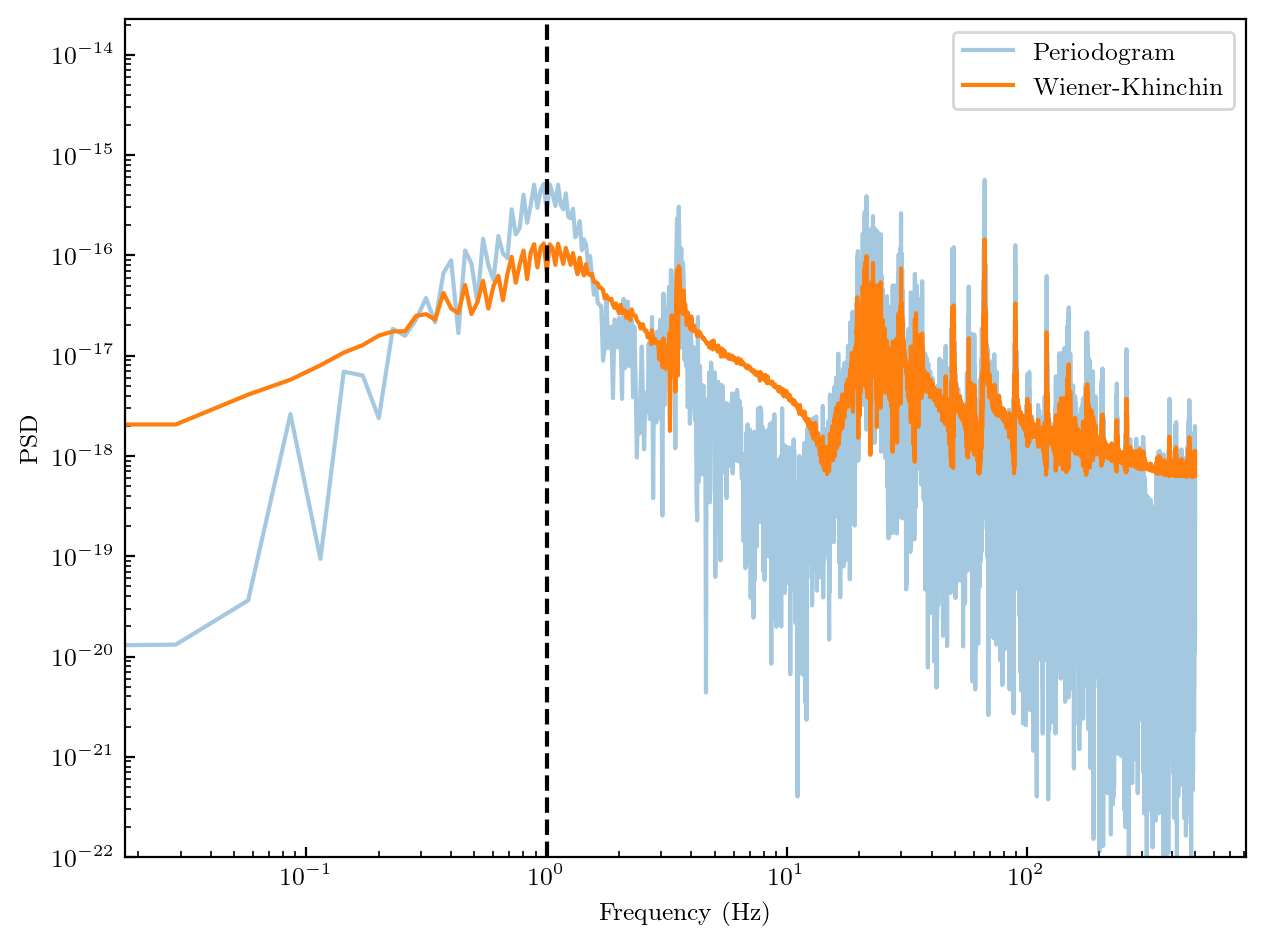

In [734]:
x = datas[:,1,1]

# ── 1. Welch ──────────────────────────────────────────────────────────────
# freqs_welch, psd_welch = signal.welch(x, fs=1/dt, nperseg=256)

# ── 2. Wiener-Khinchin (via autocorrelation) ──────────────────────────────
def autocorrelation_biased(a):
    a = a - np.mean(a)
    N = len(a)
    f = np.fft.rfft(a, n=2*N)
    acf = np.fft.irfft(f * np.conj(f))[:N]
    acf /= N  # divide by N instead of N-lag
    return acf
# acf = Cxy_fft(x, x, retrieve_mean=False) 
x_detrended = x #signal.detrend(x, type='linear')
acf = autocorrelation_biased(x_detrended)
psd_wk = np.fft.rfft(acf) * dt
freqs_wk = np.fft.rfftfreq(len(acf), d=dt)

# ── 3. Periodogram ────────────────────────────────────────────────────────
freqs_pgram, psd_pgram = signal.periodogram(x, fs=1/dt, scaling='density')

# ── Plot ──────────────────────────────────────────────────────────────────

plt.figure()
plt.loglog(freqs_pgram, psd_pgram, alpha=0.4, label='Periodogram')
plt.plot(freqs_wk, np.abs(psd_wk), label='Wiener-Khinchin')
# plt.semilogy(freqs_welch, psd_welch, lw=2, label='Welch')
plt.axvline(x=1/dt/window, ls='--', color='k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.legend()
plt.ylim([1e-22, None])
plt.tight_layout()
plt.show()

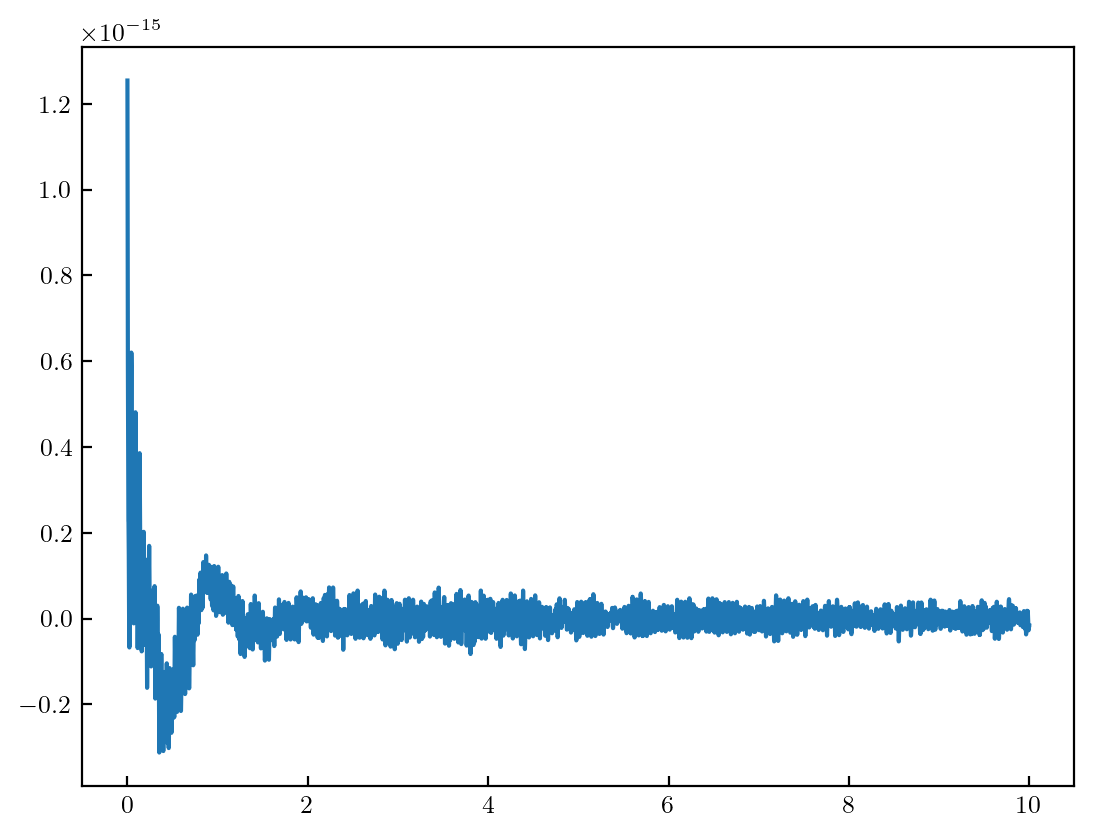

In [735]:
plt.plot(np.arange(len(acf))[:10000]*dt, acf[:10000])

In [651]:
print(np.mean(x))

1.161140223582742e-10


In [652]:
# plt.plot(x-np.nanmean(x))
# plt.plot(x_detrended)